# Test: Drifter Advection in QG Flow Field

This notebook tests `qg_drifters.jl` — advecting virtual Lagrangian drifters through the pyqg velocity fields using Drifters.jl.

In [1]:
include("jl/qg_grid.jl")
include("jl/qg_drifters.jl")
using CairoMakie, Statistics

## Run drifter simulation

Deploy 256 drifters (16x16 grid) and advect for 30 days starting from day 5000 (well past spin-up).

In [2]:
@time results = run_drifters(; t_start=5001, n_days=30, n_per_side=16, record_interval=1)
traj = results.trajectories
dx = results.dx; nx = results.nx
println("\nTrajectory table: $(nrow(traj)) rows")
first(traj, 5)

Deploying 256 drifters on 16x16 grid
Loading initial velocity field (t_idx=5001)...
  Day 10/30 complete
  Day 20/30 complete
  Day 30/30 complete
Done. 7936 trajectory records for 256 drifters over 30 days.
 10.249410 seconds (32.69 M allocations: 1.560 GiB, 13.89% gc time, 92.79% compilation time: 2% of which was recompilation)

Trajectory table: 7936 rows


Row,ID,x,y,t,x_m,y_m
,Int64,Float64,Float64,Float64,Float64,Float64
1,1,8.0,8.0,0.0,31250.0,31250.0
2,2,24.0,8.0,0.0,93750.0,31250.0
3,3,40.0,8.0,0.0,156250.0,31250.0
4,4,56.0,8.0,0.0,218750.0,31250.0
5,5,72.0,8.0,0.0,281250.0,31250.0


## Figure 1: Drifter trajectories over speed field

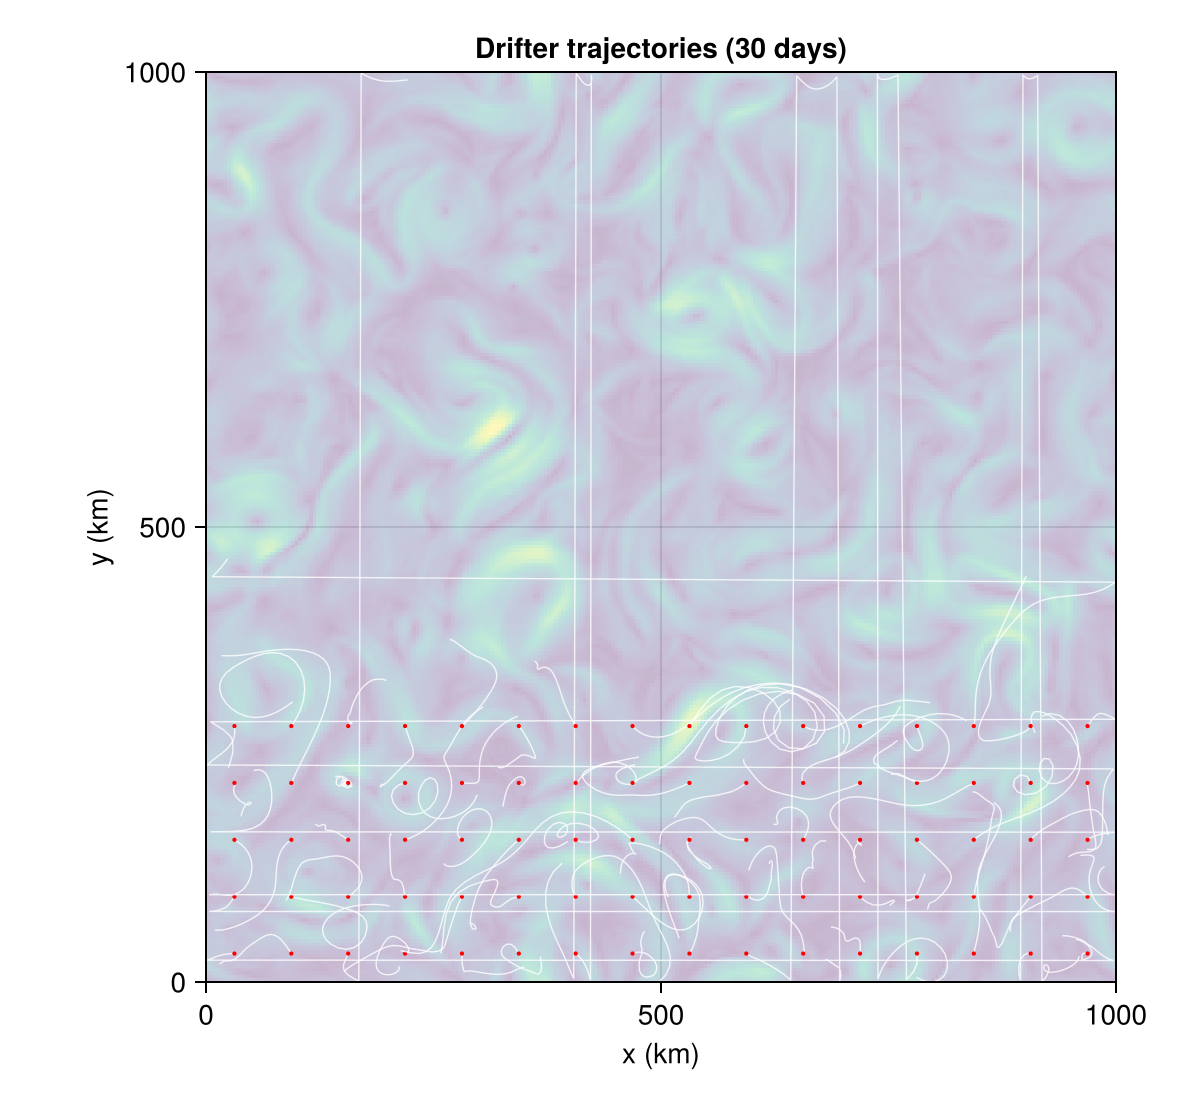

In [3]:
nc_path = joinpath(ENV["OS_DATA"], "QG", "QGModelOutput20years.nc")
γ, _, _, x, y = qg_gcmgrid(nc_path)
u_fields, v_fields, _ = load_velocity_fields(nc_path, γ; lev=1, trange=5001:5001)
x_km = x ./ 1000; y_km = y ./ 1000

fig1 = Figure(size=(600, 550))
ax1 = Axis(fig1[1,1], title="Drifter trajectories (30 days)",
    xlabel="x (km)", ylabel="y (km)", aspect=DataAspect())
speed = sqrt.(u_fields[1][1].^2 .+ v_fields[1][1].^2)
heatmap!(ax1, x_km, y_km, speed, colormap=(:viridis, 0.3))

for id in 1:min(80, results.n_drifters)
    sub = traj[traj.ID .== id, :]
    lines!(ax1, sub.x_m ./ 1000, sub.y_m ./ 1000, linewidth=0.7, color=(:white, 0.8))
    scatter!(ax1, [sub.x_m[1] / 1000], [sub.y_m[1] / 1000], markersize=3, color=:red)
end
fig1

## Figure 2: Mean displacement from origin

In [ ]:
times_days = sort(unique(traj.t)) ./ 86400
init = traj[traj.t .== 0.0, :]

mean_disp = Float64[]
for t_val in sort(unique(traj.t))
    sub = traj[traj.t .== t_val, :]
    d = sqrt.((sub.x_m .- init.x_m).^2 .+ (sub.y_m .- init.y_m).^2)
    push!(mean_disp, mean(d))
end

fig2 = Figure(size=(550, 380))
ax2 = Axis(fig2[1,1], title="Mean drifter displacement",
    xlabel="Time (days)", ylabel="Displacement (km)")
lines!(ax2, times_days, mean_disp ./ 1000, linewidth=2)
fig2

## Figure 3: Pair separation evolution

Track mean separation of 500 random drifter pairs over time (with periodic minimum-image convention).

In [ ]:
n = results.n_drifters
L = nx * dx
pair_ids = [(rand(1:n), rand(1:n)) for _ in 1:500]
filter!(p -> p[1] != p[2], pair_ids)

mean_sep = Float64[]
for t_val in sort(unique(traj.t))
    sub = traj[traj.t .== t_val, :]
    seps = Float64[]
    for (i, j) in pair_ids
        dxx = sub.x_m[i] - sub.x_m[j]
        dyy = sub.y_m[i] - sub.y_m[j]
        dxx = dxx - L * round(dxx / L)
        dyy = dyy - L * round(dyy / L)
        push!(seps, sqrt(dxx^2 + dyy^2))
    end
    push!(mean_sep, mean(seps))
end

fig3 = Figure(size=(550, 380))
ax3 = Axis(fig3[1,1], title="Mean pair separation ($(length(pair_ids)) pairs)",
    xlabel="Time (days)", ylabel="Separation (km)")
lines!(ax3, times_days, mean_sep ./ 1000, linewidth=2, color=:darkorange)
fig3

## Figure 4: Snapshot of drifter positions at different times

In [ ]:
fig4 = Figure(size=(1000, 450))
for (col, day) in enumerate([0, 10, 30])
    t_val = day * 86400.0
    sub = traj[traj.t .== t_val, :]
    ax = Axis(fig4[1, col], title="Day $day",
        xlabel="x (km)", ylabel="y (km)", aspect=DataAspect())
    heatmap!(ax, x_km, y_km, speed, colormap=(:viridis, 0.3))
    scatter!(ax, sub.x_m ./ 1000, sub.y_m ./ 1000, markersize=4, color=:red)
end
fig4